# Notebook 03 - Veri Hikayesi ve İş Analizi

## Enerji Perakende Veri Analizi Case Study

### Amaç

Bu notebook, Ahmet Çalık Vakfı İleri Veri Analitiği Eğitimi kapsamında hazırlanan enerji perakende veri analizi çalışmasının son bölümünü kapsamaktadır.

Bu bölümde yalnızca grafik üretmek yerine veriler yorumlanmış, hipotezler oluşturulmuş ve elde edilen bulgular iş bakış açısıyla değerlendirilmiştir.

Notebook kapsamında;

- İlçeler arasındaki tüketim farklılıkları incelenmiştir.
- Müşteriler tüketim ve ödeme davranışlarına göre segmentlere ayrılmıştır.
- Riskli müşteri grupları belirlenmiştir.
- Tahsilat performansı değerlendirilmiştir.
- Analiz sonuçları doğrultusunda iş geliştirme önerileri sunulmuştur.


## Problem Tanımı

Enerji perakende sektöründe müşterilerin elektrik tüketim alışkanlıkları ve ödeme davranışları operasyonel süreçlerin planlanmasında önemli rol oynamaktadır.

Bu çalışmada Hamamözü, Gümüşhacıköy ve Göynücek ilçelerine ait tahakkuk ve tahsilat verileri kullanılarak;

- İlçeler arasındaki tüketim farklılıkları,
- Mevsimsel değişimler,
- Hesap sınıflarının dağılımı,
- Tahsilat performansı,
- Ödeme davranışları

incelenmiş ve elde edilen bulgular iş geliştirme bakış açısıyla değerlendirilmiştir.

## Hipotezler

Bu analiz kapsamında aşağıdaki hipotezler test edilecektir.

**H1:** İlçeler arasında elektrik tüketim miktarları anlamlı farklılık göstermektedir.

**H2:** Yaz aylarında elektrik tüketimi artmaktadır.

**H3:** Mesken aboneleri toplam müşteri sayısının büyük bölümünü oluşturmaktadır.

**H4:** Tahsilatların büyük bölümü son ödeme tarihinden önce veya son ödeme gününde gerçekleştirilmektedir.

**H5:** Yüksek elektrik tüketimine sahip müşteri grupları daha farklı ödeme davranışı göstermektedir.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

plt.style.use("ggplot")

%matplotlib inline

# Excel dosyasının yolu
file_path = "../data/elektrik_veri.xlsx"

# Excel dosyasını açma
xls = pd.ExcelFile(file_path)

# Tahsilat veri setlerini yükleme
df_tahsilat = pd.read_excel(xls, sheet_name="Tahsilat")
df_tahsilat_1 = pd.read_excel(xls, sheet_name="Tahsilat 1")

# Tahakkuk veri setlerini yükleme
df_tahakkuk = pd.read_excel(xls, sheet_name="Tahakkuk")
df_tahakkuk_1 = pd.read_excel(xls, sheet_name="Tahakkuk 1")
df_tahakkuk_2 = pd.read_excel(xls, sheet_name="Tahakkuk 2")

# Üç ilçenin tahakkuk verilerini birleştirme
df_tahakkuk_tum = pd.concat(
    [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2],
    ignore_index=True
)

print("Tahsilat kayıt sayısı   :", len(df_tahsilat))
print("Tahsilat 1 kayıt sayısı :", len(df_tahsilat_1))
print("Tahakkuk kayıt sayısı   :", len(df_tahakkuk_tum))

Tahsilat kayıt sayısı   : 636993
Tahsilat 1 kayıt sayısı : 917632
Tahakkuk kayıt sayısı   : 1185698


---
# 1. İlçe Karşılaştırma Analizi

## Problem Tanımı

Hamamözü, Gümüşhacıköy ve Göynücek ilçelerinin elektrik tüketim seviyeleri birbirinden farklıdır.

Bu bölümde söz konusu farklılıkların;

- müşteri sayısı,
- ortalama ve medyan tüketim,
- hesap sınıfı dağılımı,
- mevsimsel tüketim eğilimleri

ile ilişkisi incelenecektir.

## Hipotezler

**H1:** Gümüşhacıköy, müşteri sayısının ve ticari faaliyetlerin daha yüksek olması nedeniyle en yüksek ortalama elektrik tüketimine sahiptir.

**H2:** Hamamözü, daha az müşteri ve daha düşük ticari yoğunluk nedeniyle en düşük tüketim seviyesine sahiptir.

**H3:** Göynücek'te tarımsal faaliyetlerin tüketim üzerindeki etkisi diğer ilçelere göre daha belirgindir.

**H4:** Üç ilçede de yaz aylarında ortalama elektrik tüketimi artmaktadır.

In [4]:
# İlçelere göre temel tüketim istatistikleri

ilce_ozet = (
    df_tahakkuk_tum
    .groupby("ilce")
    .agg(
        Musteri_Sayisi=("sozlesme_hesap_no", "nunique"),
        Kayit_Sayisi=("sozlesme_hesap_no", "size"),
        Ortalama_Tuketim_kWh=("kwh", "mean"),
        Medyan_Tuketim_kWh=("kwh", "median"),
        Toplam_Tuketim_kWh=("kwh", "sum")
    )
    .round(2)
    .sort_values("Ortalama_Tuketim_kWh", ascending=False)
)

ilce_ozet

,Musteri_Sayisi,Kayit_Sayisi,Ortalama_Tuketim_kWh,Medyan_Tuketim_kWh,Toplam_Tuketim_kWh
ilce,,,,,
GÜMÜŞHACIKÖY,18190,765657,97.34,48.31,74526473.58
GÖYNÜCEK,7128,295223,89.67,45.09,26472614.19
HAMAMÖZÜ,2981,124818,70.87,40.56,8846428.21


### Bulgular

İlçelere ait temel tüketim istatistikleri incelendiğinde aşağıdaki sonuçlara ulaşılmıştır:

- **Gümüşhacıköy**, hem en yüksek müşteri sayısına hem de en yüksek toplam elektrik tüketimine sahiptir.
- **Göynücek**, müşteri sayısı bakımından ikinci sırada yer almakta olup ortalama tüketim değeri de yüksektir.
- **Hamamözü**, hem müşteri sayısı hem de toplam tüketim açısından en düşük değerlere sahiptir.
- Medyan tüketim değerlerinin ortalamadan düşük olması, yüksek tüketim yapan abonelerin ortalamayı yukarı çektiğini göstermektedir.

### İş Önerileri

- Gümüşhacıköy ilçesi, yüksek müşteri ve tüketim yoğunluğu nedeniyle operasyonel planlamada öncelikli bölge olarak değerlendirilebilir.
- Hamamözü ilçesinde düşük tüketim seviyelerinin nedenleri araştırılarak enerji verimliliği ve müşteri davranışları analiz edilebilir.
- Ortalama ve medyan tüketim arasındaki farkın yüksek olması nedeniyle yüksek tüketimli aboneler için ayrı müşteri segmentleri oluşturulması önerilmektedir.

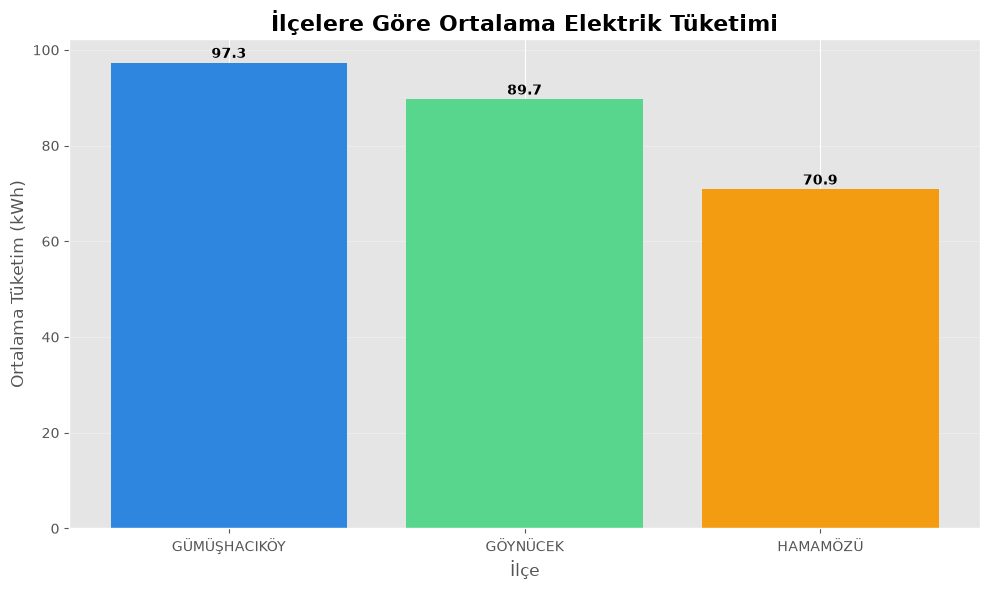

In [5]:
plt.figure(figsize=(10,6))

plt.bar(
    ilce_ozet.index,
    ilce_ozet["Ortalama_Tuketim_kWh"],
    color=["#2E86DE", "#58D68D", "#F39C12"]
)

plt.title(
    "İlçelere Göre Ortalama Elektrik Tüketimi",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("İlçe")
plt.ylabel("Ortalama Tüketim (kWh)")

plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(ilce_ozet["Ortalama_Tuketim_kWh"]):
    plt.text(
        i,
        v + 1,
        f"{v:.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/notebook3_ilce_ortalama_tuketim.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

# 2. Müşteri Segmentasyonu

## Problem Tanımı

Elektrik tüketim seviyeleri müşteriler arasında önemli farklılıklar göstermektedir.

Bu bölümde müşteriler tüketim miktarlarına göre segmentlere ayrılarak her grubun büyüklüğü ve ortalama tüketim değerleri incelenmektedir. Benzer şekilde ödeme davranışları da müşteriler arasında farklılık göstermektedir.

Bu bölümde müşteriler elektrik tüketim miktarlarına göre segmentlere ayrılarak her grubun temel özellikleri incelenecektir.

## Hipotezler

**H1:** Elektrik tüketimi arttıkça ödeme davranışı farklılaşmaktadır.

**H2:** Düşük tüketimli müşteri grupları toplam müşteri kitlesinin büyük bölümünü oluşturmaktadır.

**H3:** Yüksek tüketimli müşteriler toplam tüketimin önemli bölümünü gerçekleştirmektedir.

In [6]:
# Tüketim değişkeninin temel istatistikleri

df_tahakkuk_tum["kwh"].describe()

count    1.185698e+06
mean     9.264207e+01
std      9.504052e+02
min     -2.537064e+04
25%      1.801000e+01
50%      4.662000e+01
75%      8.000000e+01
max      1.535757e+05
Name: kwh, dtype: float64

In [ ]:
# Negatif tüketimleri analiz dışında bırakma
df_segment = df_tahakkuk_tum[
    df_tahakkuk_tum["kwh"] >= 0
].copy()

# Tüketim segmentlerini oluşturma
df_segment["Tuketim_Segmenti"] = pd.cut(
    df_segment["kwh"],
    bins=[0, 50, 150, 500, float("inf")],
    labels=[
        "Düşük Tüketim",
        "Orta Tüketim",
        "Yüksek Tüketim",
        "Çok Yüksek Tüketim"
    ],
    include_lowest=True
)

segment_ozet = (
    df_segment
    .groupby("Tuketim_Segmenti")
    .agg(
        Musteri_Sayisi=("sozlesme_hesap_no", "nunique"),
        Kayit_Sayisi=("sozlesme_hesap_no", "size"),
        Ortalama_Tuketim=("kwh", "mean")
    )
    .round(2)
)

segment_ozet

,Musteri_Sayisi,Kayit_Sayisi,Ortalama_Tuketim
Tuketim_Segmenti,,,
Düşük Tüketim,26506,628851,20.89
Orta Tüketim,20646,489370,83.28
Yüksek Tüketim,6462,55285,222.64
Çok Yüksek Tüketim,855,12041,3634.20


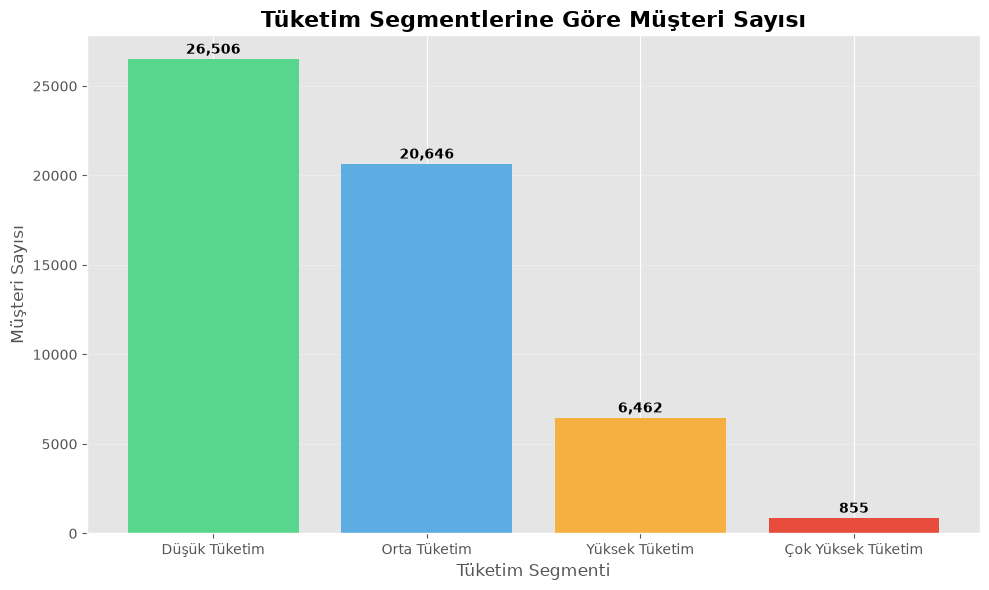

In [9]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    segment_ozet.index,
    segment_ozet["Musteri_Sayisi"],
    color=[
        "#58D68D",
        "#5DADE2",
        "#F5B041",
        "#E74C3C"
    ]
)

plt.title(
    "Tüketim Segmentlerine Göre Müşteri Sayısı",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tüketim Segmenti")
plt.ylabel("Müşteri Sayısı")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 300,
        f"{int(height):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/musteri_segmentleri.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Bulgular

Segmentasyon sonucunda müşterilerin büyük bölümünün düşük ve orta tüketim grubunda yer aldığı görülmüştür.

Çok yüksek tüketim segmentinde yer alan müşteri sayısı oldukça düşük olmasına rağmen bu grup yüksek enerji tüketimi gerçekleştirmektedir.

Bu durum enerji şirketleri açısından yüksek tüketimli müşterilerin ayrı bir segment olarak yönetilmesi gerektiğini göstermektedir.

### İş Önerileri

- Çok yüksek tüketim gerçekleştiren müşterilere özel enerji verimliliği programları geliştirilebilir.
- Yüksek tüketimli müşteriler için özel müşteri temsilcisi veya öncelikli hizmet modeli uygulanabilir.
- Düşük tüketimli müşterilere yönelik dijital self-servis hizmetler artırılarak operasyonel maliyetler azaltılabilir.

---

# 3. Tahsilat Performans Analizi

## Problem Tanımı

Tahsilatların hangi ödeme dönemlerinde yoğunlaştığını belirlemek, müşteri ödeme davranışlarını anlamak ve tahsilat süreçlerini iyileştirmek açısından önemlidir.

Bu bölümde ödeme dönemlerine göre tahsilat dağılımı değerlendirilerek tahsilat performansı analiz edilecektir.

## Hipotezler

**H1:** Tahsilatların büyük bölümü son ödeme tarihinde veya öncesinde gerçekleşmektedir.

**H2:** Gecikme süresi arttıkça tahsil edilen tutar azalmaktadır.

**H3:** Uzun süre gecikmiş tahsilatlar toplam tahsilat içerisinde oldukça düşük paya sahiptir.

### Bulgular

Ödeme dönemlerine göre yapılan analiz sonucunda tahsilatların büyük bölümünün son ödeme tarihinde veya son ödeme tarihinden önce gerçekleştirildiği görülmüştür.

Son ödeme tarihinden sonraki tahsilatlar gecikme süresi arttıkça düzenli olarak azalmaktadır. Özellikle 90 gün ve üzerindeki gecikmeler toplam tahsilat içerisinde oldukça düşük bir paya sahiptir.

Bu durum müşterilerin büyük çoğunluğunun ödeme yükümlülüklerini zamanında yerine getirdiğini göstermektedir.

### İş Önerileri

- Son ödeme tarihinden önce ödeme yapan müşterilere yönelik dijital teşvik uygulamaları geliştirilebilir.
- Gecikme riski taşıyan müşteriler için erken uyarı sistemleri kurulabilir.
- Uzun süre gecikmiş tahsilatlar için özel takip ve tahsilat stratejileri uygulanabilir.
- Tahsilat performansı düzenli olarak izlenerek riskli müşteri grupları erken aşamada tespit edilebilir.

# Sonuç

Bu çalışma kapsamında elektrik tahakkuk ve tahsilat verileri analiz edilerek ilçeler bazında tüketim farklılıkları, müşteri segmentleri ve tahsilat performansı incelenmiştir.

Analizler sonucunda;

- Gümüşhacıköy ilçesinin en yüksek tüketim düzeyine sahip olduğu,
- Müşterilerin büyük bölümünün düşük ve orta tüketim segmentinde yer aldığı,
- Çok yüksek tüketim gerçekleştiren az sayıdaki müşterinin önemli bir tüketim payına sahip olduğu,
- Tahsilatların büyük kısmının son ödeme tarihinde veya öncesinde gerçekleştiği

tespit edilmiştir.

Bu bulgular, müşteri segmentasyonu, tahsilat süreçlerinin iyileştirilmesi ve enerji yönetimi açısından karar vericilere yol gösterecek niteliktedir.